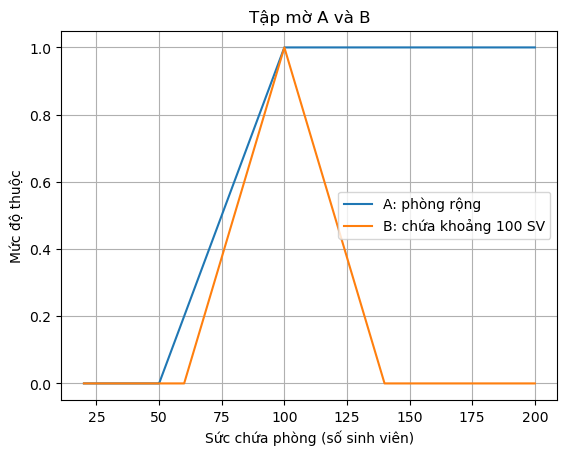

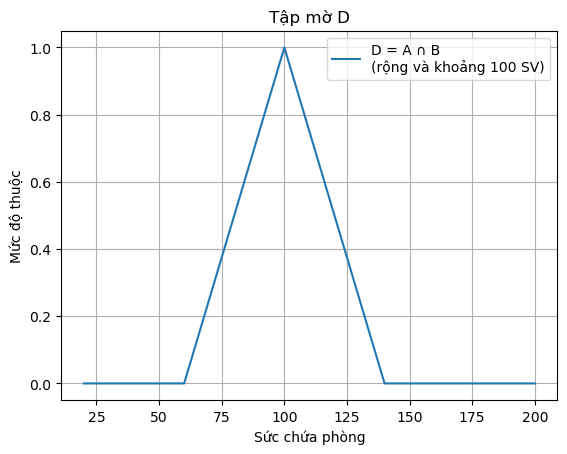

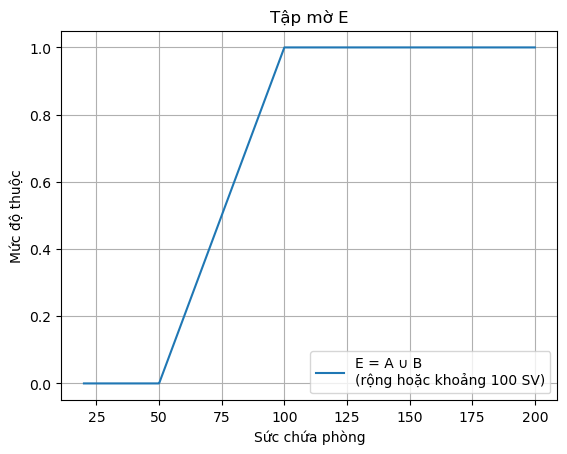

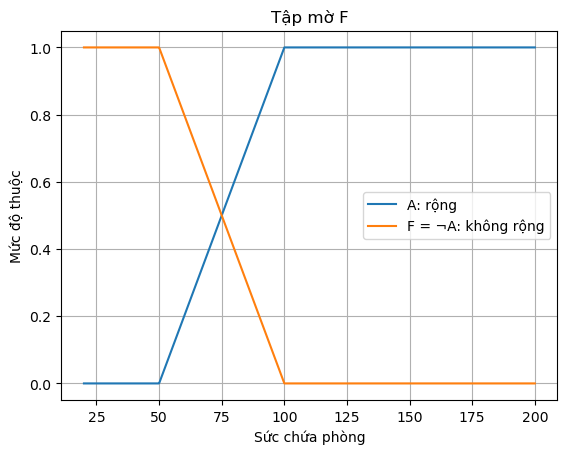

Suc chua | mu_A (rộng) | mu_B (~100) | mu_D | mu_E | mu_F (không rộng)
     40 |         0.00 |        0.00 |  0.00 |  0.00 |     1.00
     60 |         0.20 |        0.00 |  0.00 |  0.20 |     0.80
     80 |         0.60 |        0.50 |  0.50 |  0.60 |     0.40
    100 |         1.00 |        1.00 |  1.00 |  1.00 |     0.00
    120 |         1.00 |        0.50 |  0.50 |  1.00 |     0.00
    150 |         1.00 |        0.00 |  0.00 |  1.00 |     0.00


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Không gian nền: sức chứa phòng, từ 20 đến 200 SV
c = np.linspace(20, 200, 1000)  # capacity

# 2. Hàm thuộc cho A: "phòng rộng"
def mu_A(c):
    c = np.asarray(c)
    mu = np.zeros_like(c, dtype=float)
    # 50-100: tăng từ 0 -> 1
    mask1 = (c >= 50) & (c < 100)
    mu[mask1] = (c[mask1] - 50) / 50.0
    # >=100: rất rộng
    mask2 = (c >= 100)
    mu[mask2] = 1.0
    return mu

# 3. Hàm thuộc cho B: "chứa khoảng 100 SV" (tam giác 60-100-140)
def mu_B(c):
    c = np.asarray(c)
    mu = np.zeros_like(c, dtype=float)
    # 60-100: tăng từ 0 -> 1
    mask1 = (c >= 60) & (c < 100)
    mu[mask1] = (c[mask1] - 60) / 40.0
    # 100-140: giảm từ 1 -> 0
    mask2 = (c >= 100) & (c <= 140)
    mu[mask2] = (140 - c[mask2]) / 40.0
    return mu

A = mu_A(c)
B = mu_B(c)

# 4. Xây dựng D, E, F
D = np.minimum(A, B)   # A ∩ B: phòng rộng và khoảng 100 SV
E = np.maximum(A, B)   # A ∪ B: phòng rộng hoặc khoảng 100 SV
F = 1 - A              # ¬A: phòng không rộng

# 5. Vẽ A và B
plt.figure()
plt.plot(c, A, label="A: phòng rộng")
plt.plot(c, B, label="B: chứa khoảng 100 SV")
plt.xlabel("Sức chứa phòng (số sinh viên)")
plt.ylabel("Mức độ thuộc")
plt.title("Tập mờ A và B")
plt.grid(True)
plt.legend()
plt.show()

# 6. Vẽ D = A ∩ B
plt.figure()
plt.plot(c, D, label="D = A ∩ B\n(rộng và khoảng 100 SV)")
plt.xlabel("Sức chứa phòng")
plt.ylabel("Mức độ thuộc")
plt.title("Tập mờ D")
plt.grid(True)
plt.legend()
plt.show()

# 7. Vẽ E = A ∪ B
plt.figure()
plt.plot(c, E, label="E = A ∪ B\n(rộng hoặc khoảng 100 SV)")
plt.xlabel("Sức chứa phòng")
plt.ylabel("Mức độ thuộc")
plt.title("Tập mờ E")
plt.grid(True)
plt.legend()
plt.show()

# 8. Vẽ F = ¬A
plt.figure()
plt.plot(c, A, label="A: rộng")
plt.plot(c, F, label="F = ¬A: không rộng")
plt.xlabel("Sức chứa phòng")
plt.ylabel("Mức độ thuộc")
plt.title("Tập mờ F")
plt.grid(True)
plt.legend()
plt.show()

# 9. Minh hoạ với vài phòng cụ thể
capacities = np.array([40, 60, 80, 100, 120, 150])
rooms_A = mu_A(capacities)
rooms_B = mu_B(capacities)
rooms_D = np.minimum(rooms_A, rooms_B)
rooms_E = np.maximum(rooms_A, rooms_B)
rooms_F = 1 - rooms_A

print("Suc chua | mu_A (rộng) | mu_B (~100) | mu_D | mu_E | mu_F (không rộng)")
for cap, a, b, d, e, f in zip(capacities, rooms_A, rooms_B, rooms_D, rooms_E, rooms_F):
    print(f"{cap:7d} | {a:12.2f} | {b:11.2f} | {d:5.2f} | {e:5.2f} | {f:8.2f}")
